# Financial Econometrics I – Project: Asset 12
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)


**Team Project**

**Individual contributions**:

**AI tool usage**: 

**Data used**: `Asset 12`

---

## Setup

In [1]:
library(xts)
library(zoo)
library(forecast)
library(lmtest)
library(sandwich)
library(ggplot2)
library(fGarch)
library(tseries)

options(repr.plot.width = 12, repr.plot.height = 7)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


NOTE: Packages 'fBasics', 'timeDate', and 'timeSeries' are no longer
attached to the search() path when 'fGarch' is attached.

If needed attach them yourself in your R script by e.g.,
        require("timeSeries")

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [2]:
#Loading data

load("12.RData")
dates <- as.Date(index(adp))
df <- data.frame(date = dates, coredata(adp))
n <- nrow(df)

str(df)
colSums(is.na(df))
head(df)

'data.frame':	1500 obs. of  7 variables:
 $ date: Date, format: "2010-01-05" "2010-01-06" ...
 $ ret : num  -0.02065 0.00351 -0.01578 0.00686 0 ...
 $ RV  : num  0.00735 0.00726 0.00825 0.01071 0.00819 ...
 $ RV_p: num  0.00541 0.00527 0.00638 0.00832 0.00587 ...
 $ RV_n: num  0.00498 0.00499 0.00522 0.00674 0.00572 ...
 $ RS  : num  0.14174 0.37146 0.63841 0.82536 -0.00218 ...
 $ RK  : num  4.47 4.65 5.18 8.59 3.6 ...


date  ret   RV RV_p RV_n   RS   RK 
   0    0    0    0    0    0    0

,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2010-01-05,-0.020653180,0.007350539,0.005405043,0.004981559,0.141740222,4.466892
2,2010-01-06,0.003511290,0.007256418,0.005266342,0.004992118,0.371460566,4.651872
3,2010-01-07,-0.015778928,0.008245743,0.006380770,0.005222840,0.638412801,5.184831
4,2010-01-08,0.006858424,0.010708223,0.008319662,0.006741607,0.825360610,8.589113
5,2010-01-11,0.000000000,0.008192468,0.005868996,0.005715893,-0.002182018,3.595589
6,2010-01-12,-0.001415029,0.008020262,0.005308244,0.006012250,-0.331897832,2.665040


---
# 1. Data Description

The dataset contains 1,500 daily observations of Asset 12 over time period of January 2010 through January 2016. Six variables are included: returns (ret), volatility (RV), positive realized semi-variability (RV_p) and negative realized semi-variability (RV_n), realized skewness (RS) and realized kurtosis (RK). No data is missing.

## Descriptive Statistics

In [18]:
vars <- c("ret", "RV", "RV_p", "RV_n", "RS", "RK")

#Functions for sample skewness and excess kurtosis

skew <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  n / ((n - 1) * (n - 2)) * sum(((x - x_bar) / s)^3)}

kurt <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  term1 <- (n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3))
  term2 <- 3 * (n - 1)^2 / ((n - 2) * (n - 3))
  
  term1 * sum(((x - x_bar) / s)^4) - term2}

desc <- data.frame(
  variable = vars,
  mean = sapply(vars, function(v) mean(df[[v]])),
  median = sapply(vars, function(v) median(df[[v]])),
  sd = sapply(vars, function(v) sd(df[[v]])),
  min = sapply(vars, function(v) min(df[[v]])),
  max = sapply(vars, function(v) max(df[[v]])),
  skewness = sapply(vars, function(v) skew(df[[v]])),
  ex_kurt = sapply(vars, function(v) kurt(df[[v]])))

desc

,variable,mean,median,sd,min,max,skewness,ex_kurt
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ret,ret,0.0005218686,0.0007241519,0.012578789,-0.131236549,0.06243346,-0.9302007,11.436323
RV,RV,0.0088785142,0.0080673202,0.004339914,0.003333799,0.09566730,8.3418201,138.230808
RV_p,RV_p,0.0062363592,0.0057158182,0.003394104,0.001701334,0.09319562,12.6124728,295.395604
RV_n,RV_n,0.0061827732,0.0055447129,0.003004198,0.001677954,0.05951545,5.3782457,72.712875
RS,RS,0.0111848795,0.0163761443,1.127604586,-8.113844958,6.62202196,-0.3867348,5.018323
RK,RK,6.1156943032,4.6177594326,4.902786279,2.153265292,69.69762756,4.8768762,38.279708


The **returns** appear to be close to zero mean, yet are skewed negatively toward the left with positive excess kurtosis. This is common when describing the characteristics of financial returns. **Realized Volatility (RV)** appears to be right skewed; the mean is greater than the median, and has some larger spikes within the dataset reflecting volatility clustering. The two realized semi-variabilities **(RV_p & RV_n)** have nearly identical means in this example, although it may be an anomaly of this particular asset. **Realized Skewness (RS)** is centered on zero, however, can range anywhere from approximately (- 8) to (+ 6). Therefore, there will occasionally be days where the intraday asymmetry will be significantly different from average. **Realized Kurtosis (RK)** is generally well above 3 and is also highly right skewed indicating that many days' returns exhibit more severe tailed distributions than those described by a standard normal distribution.

## Time Series Plots

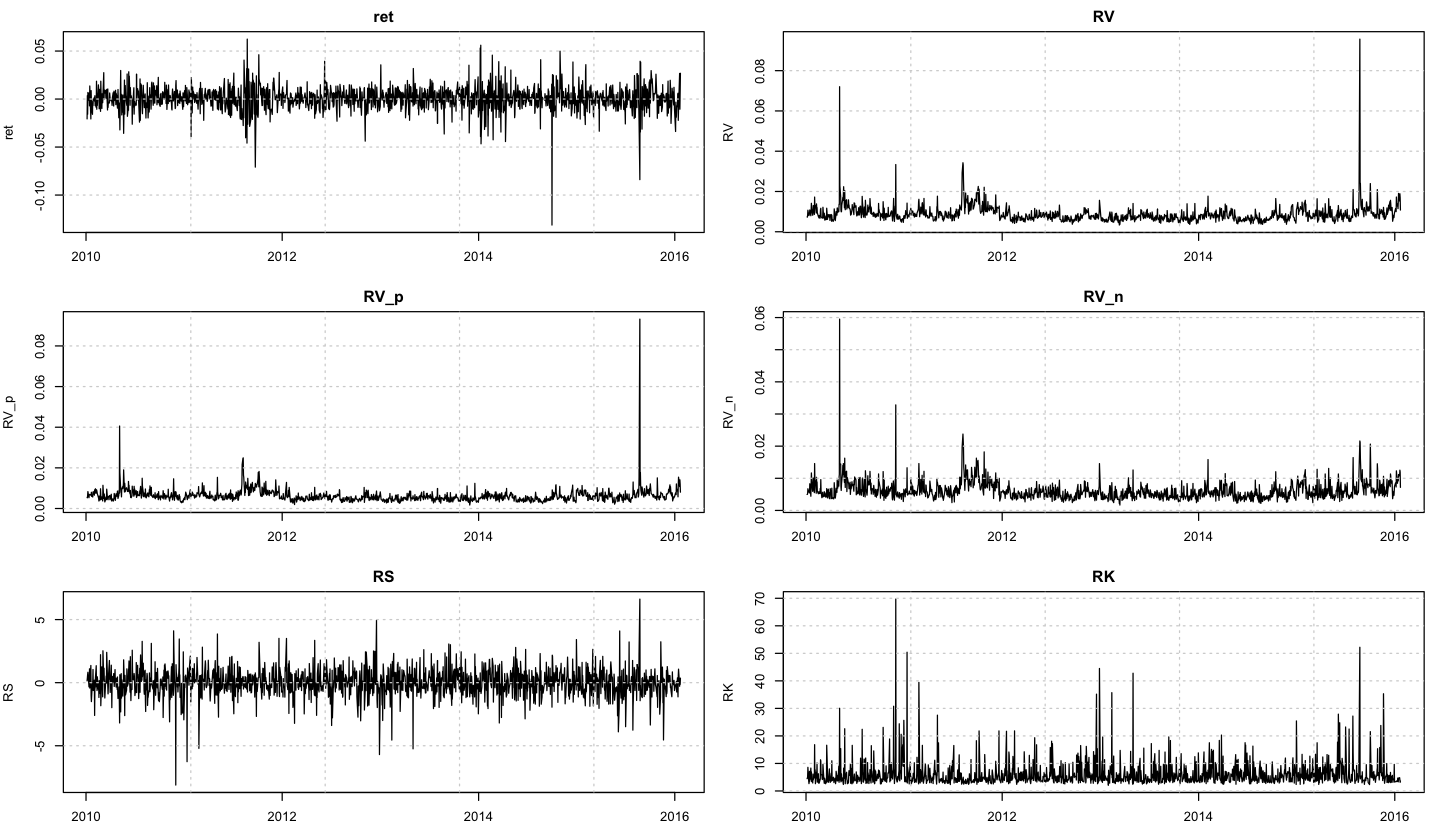

In [19]:
par(mfrow = c(3, 2), mar = c(3, 4, 2, 1))
for (v in vars) {
  plot(df$date, df[[v]], type = "l", main = v, xlab = "", ylab = v)
  grid()
}

The evidence from RV clearly demonstrates that the returns exhibit **"volatility clustering"** (i.e., periods of calm markets and those of turbulence) and that periods of high volatility in the returns typically remain so for a number of weeks. The returns appear to be roughly stationary; however, they do occasionally experience large negative shocks. The movement of both **RV_p and RV_n** can be said to be very similar, yet are never identical. **RS**  occasionally has an extreme spike when the stock's price or volume exhibits unusual behavior throughout the trading day.

## ACF Plots

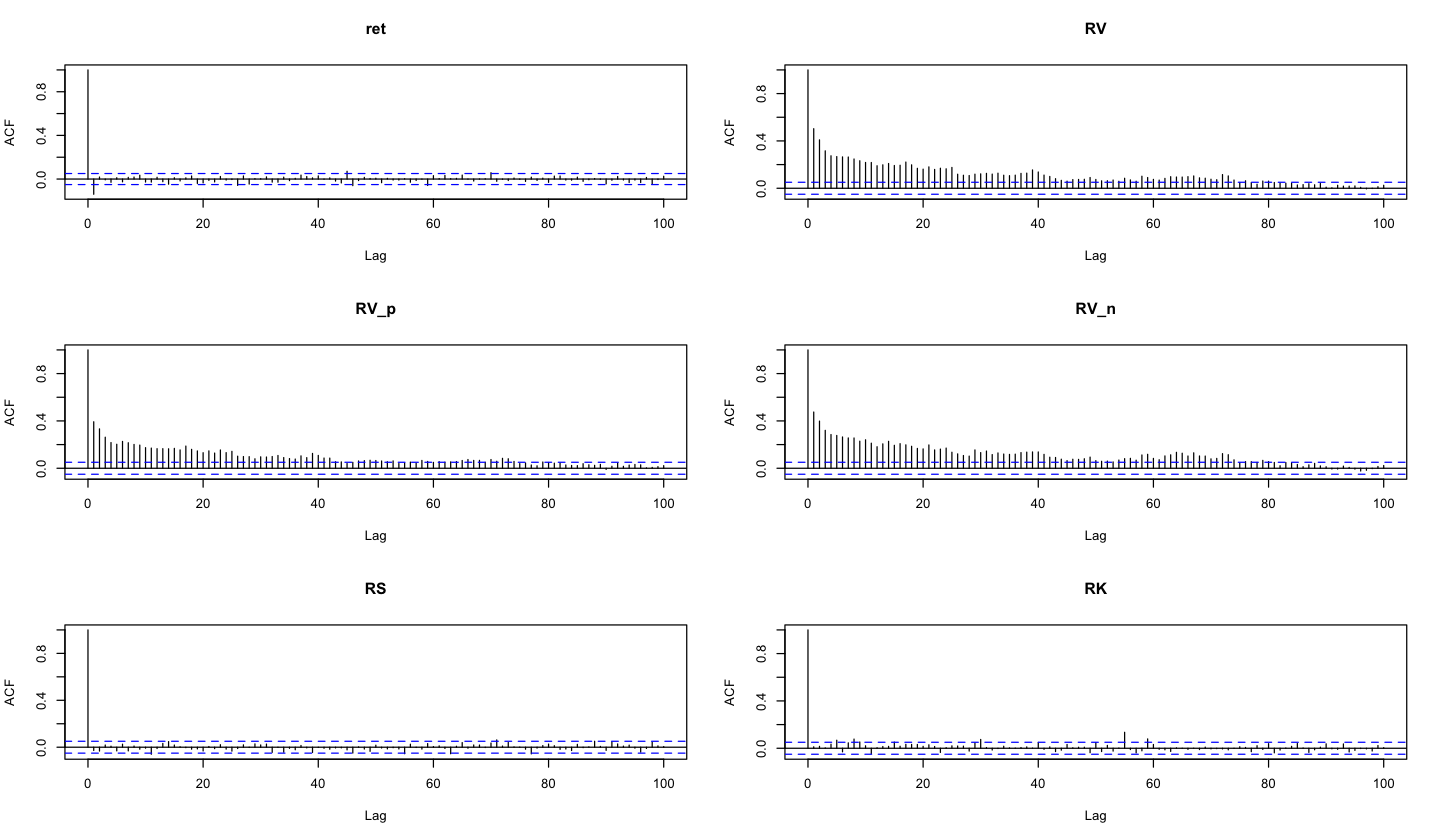

In [20]:
par(mfrow = c(3, 2))
for (v in vars) {
  acf(df[[v]], lag.max = 100, main = paste(v))
}

**Returns** demonstrate almost no serial correlation at any lag, which indicates that the market is efficient. **RV, RV_p, and RV_n** also demonstrate a strong autocorrelation that is relatively slow to decay. This suggests the presence of persistent volatility dynamics that motivates the use of the HAR (Heterogeneous Autoregressive) model. **RS** is close to a white noise and therefore it displays characteristics typical of such as well as nearly no autocorrelation. **RK** has some level of serial correlation at shorter lags; however, this autocorrelation dissipates much quicker than the autocorrelations seen in the volatility measures.

## Histograms & Density

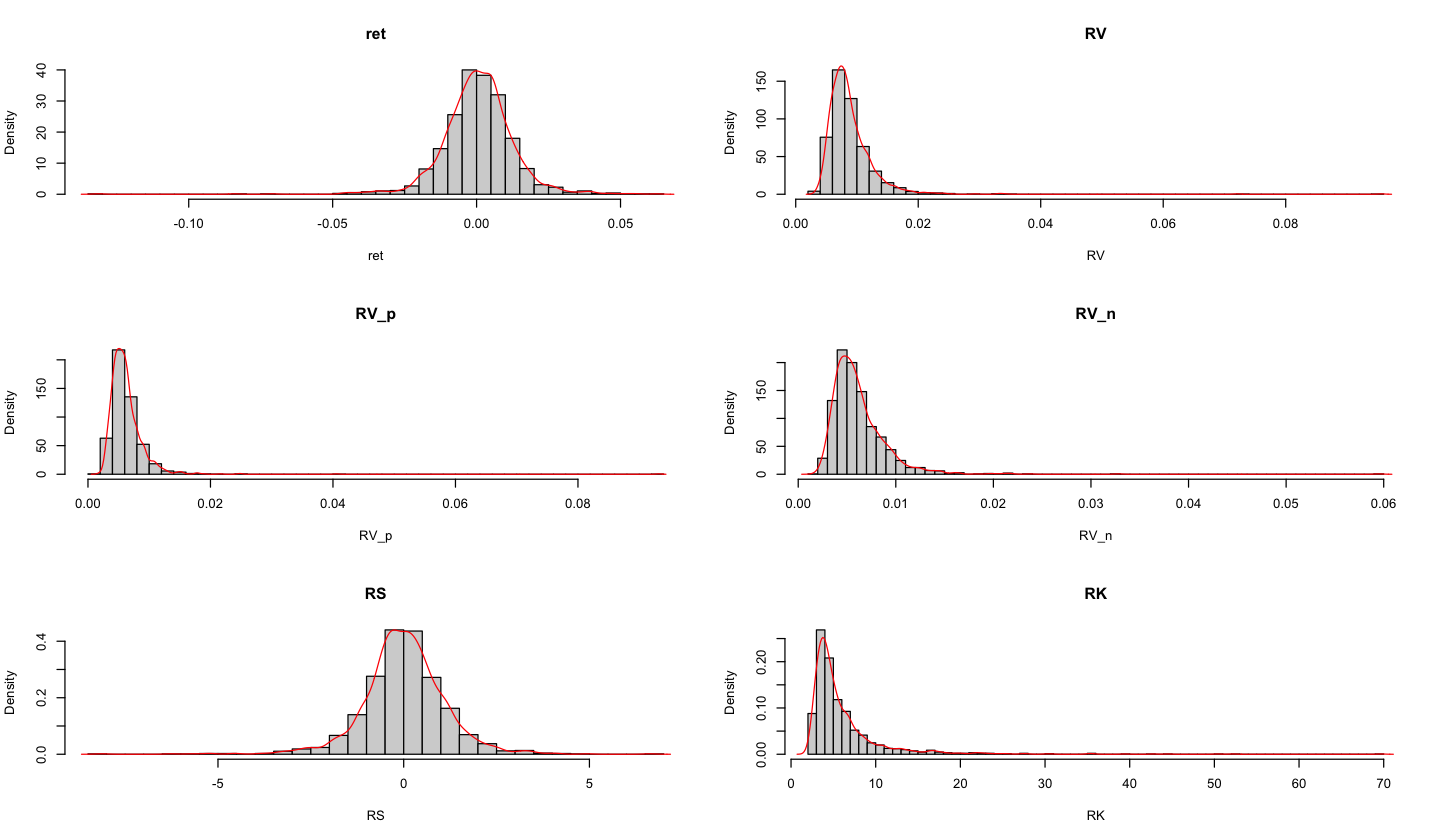

In [21]:
par(mfrow = c(3, 2))
for (v in vars) {
  hist(df[[v]], breaks = 50, main = v, xlab = v, freq = FALSE)
  lines(density(df[[v]]), col = "red")
}

The **returns** appear to be normally distributed; however, they have "fatter tails" than those of a true normal distribution (which corresponds to the excess kurtosis reported in the descriptive statistics). All **three RV metrics** are skewed toward the right with an extended tail - i.e., most of the time, intraday volatilities are relatively low, but from time-to-time, volatility spikes significantly. **RS** appears to be approximately symmetrical around zero but it is even more heavily tailed than a normal distribution (so substantial intra-day skewness occurs at times). **RK** is centered around 3-5, but it also has a significant amount of mass in its upper-right tail, with some large outliers present for days when both intra-day returns are characterized by large amounts of heavy-tail behavior.

# 2. In-Sample Fit

We estimate **six volatility models** for all of our sample data. Our HAR family models have as their dependent variable $RV_t$. Our GARCH family models measure the conditional volatility of stock price returns and map that back onto the RV scale via a measurement equation

## Constructing Regressors

The HAR family has three measures of how long past volatilities continue in some form of past behavior. Those are **daily**, **weekly** (a 5-day average) and **monthly** (a 22-day average). All regressors are lagged by one day to ensure we use only information available at time $t-1$.

In [22]:
#Extracting the variables used in the models

RV <- df$RV
ret <- df$ret
RV_p <- df$RV_p
RV_n <- df$RV_n
RS <- df$RS
RK <- df$RK

#Function for trailing moving averages

ma <- function(x, k) {
  as.numeric(stats::filter(x, rep(1 / k, k), sides = 1))
}

#Weekly & monthly averages

RV_w <- ma(RV, 5)
RV_m <- ma(RV, 22)

RVp_w <- ma(RV_p, 5)
RVp_m <- ma(RV_p, 22)

RVn_w <- ma(RV_n, 5)
RVn_m <- ma(RV_n, 22)

RS_w <- ma(RS, 5)
RS_m <- ma(RS, 22)

RK_w <- ma(RK, 5)
RK_m <- ma(RK, 22)

#Starting from observation 23 because the 22-day average needs enough past data

s <- 23

model_df <- data.frame(
  date = df$date[s:n],
  RV = RV[s:n],
  
  RV_lag1 = RV[(s - 1):(n - 1)],
  RV_w = RV_w[(s - 1):(n - 1)],
  RV_m = RV_m[(s - 1):(n - 1)],
  
  RVp_lag1 = RV_p[(s - 1):(n - 1)],
  RVn_lag1 = RV_n[(s - 1):(n - 1)],
  RVp_w = RVp_w[(s - 1):(n - 1)],
  RVn_w = RVn_w[(s - 1):(n - 1)],
  RVp_m = RVp_m[(s - 1):(n - 1)],
  RVn_m = RVn_m[(s - 1):(n - 1)],
  
  RS_lag1 = RS[(s - 1):(n - 1)],
  RS_w = RS_w[(s - 1):(n - 1)],
  RS_m = RS_m[(s - 1):(n - 1)],
  
  RK_lag1 = RK[(s - 1):(n - 1)],
  RK_w = RK_w[(s - 1):(n - 1)],
  RK_m = RK_m[(s - 1):(n - 1)],
  
  ret_lag1 = ret[(s - 1):(n - 1)])

model_df <- na.omit(model_df)

nrow(model_df)

[1] 1478

## Model 1: AR(1)-RV

$$RV_t = \beta_0 + \beta_1\, RV_{t-1} + \varepsilon_t$$

In [23]:
m1 <- lm(RV ~ RV_lag1, data = model_df)

summary(m1)


Call:
lm(formula = RV ~ RV_lag1, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.028461 -0.001651 -0.000438  0.000946  0.081357 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.004398   0.000222   19.81   <2e-16 ***
RV_lag1     0.503519   0.022485   22.39   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003767 on 1476 degrees of freedom
Multiple R-squared:  0.2536,	Adjusted R-squared:  0.2531 
F-statistic: 501.5 on 1 and 1476 DF,  p-value: < 2.2e-16


The **AR(1) coefficient** on the lagged RV is nearly **0.50** and highly significant. Thus, we can see a large amount of day-to-day persistence in volatility. We find an adjusted R² of approximately **0.25** - a quarter of the variance in the current day's volatility is explained by the previous day's volatility. This is the simplest baseline.

## Model 2: HAR-RV

$$RV_t = \beta_0 + \beta_d\, RV_{t-1} + \beta_w\, RV_{t-1}^{(w)} + \beta_m\, RV_{t-1}^{(m)} + \varepsilon_t$$

In [24]:
m2 <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

summary(m2)


Call:
lm(formula = RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018237 -0.001543 -0.000375  0.000985  0.082325 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0016237  0.0003591   4.521 6.63e-06 ***
RV_lag1     0.3226509  0.0299412  10.776  < 2e-16 ***
RV_w        0.1932316  0.0529429   3.650 0.000272 ***
RV_m        0.3015702  0.0582013   5.181 2.51e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003641 on 1474 degrees of freedom
Multiple R-squared:  0.3036,	Adjusted R-squared:  0.3022 
F-statistic: 214.2 on 3 and 1474 DF,  p-value: < 2.2e-16


We find all of these components of volatility persistence to be **statistically significant**. The daily lagged term provides the largest contribution to volatility persistence (approximately 0.32). It represents a measure of short-term persistence in volatility. Next, we find the weekly average term contributing a smaller portion of total variability in volatility (around 0.19). Therefore, it provides evidence of medium-term volatility clustering. Lastly, we also indentify the monthly average term to be statistically significant and provided another, larger, portion of total variability in volatility (approximately 0.30). Finally, we can see a substantial increase in the adjusted R² to nearly 0.30 that indicates volatility persistence occuring on multiple time scales simultaneously.

## Model 3: HAR-RS (Realized Semivariances)

We split RV into positive (RV_p) and negative (RV_n) semi-volatility for each of our three time horizons based on Patton & Sheppard (2015). In our data, RV_p and RV_n are semi-volatilities – they satisfy $RV_p^2 + RV_n^2 = RV^2$ rather than summing to RV directly. This enables the predictive power of upside versus downside movements to be different for future volatility. 

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)} + \varepsilon_t$$

In [25]:
m3 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df)

summary(m3)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015436 -0.001529 -0.000345  0.000964  0.082062 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0014300  0.0003587   3.986 7.04e-05 ***
RVp_lag1    0.1819176  0.0410720   4.429 1.02e-05 ***
RVn_lag1    0.3605367  0.0489478   7.366 2.92e-13 ***
RVp_w       0.0783204  0.1028962   0.761   0.4467    
RVn_w       0.1724096  0.1150019   1.499   0.1340    
RVp_m       0.0193103  0.2012518   0.096   0.9236    
RVn_m       0.3905262  0.2129960   1.833   0.0669 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003602 on 1471 degrees of freedom
Multiple R-squared:  0.3197,	Adjusted R-squared:  0.317 
F-statistic: 115.2 on 6 and 1471 DF,  p-value: < 2.2e-16


The daily semi-volatility coefficient of around (- 0.36) is approximately double that of its positive counterpart (+ 0.18), each of which is statistically significant. Both results align with a **leverage-type asymmetry**; large down-side movements generally forecast larger subsequent volatilities relative to corresponding up-side movements. At the longer horizons, weekly and monthly terms, various coefficients are in agreement as far as the signs, however most do not reach statistical significance. Adjusted $R^2$ is around 0.32 and it shows an improvement on the standard HAR. Thus, separation of positive and negative variation adds predictive power. 

## Model 4: HAR-Rskew-Rkurt

We augment the HAR-RS model with realized skewness and realized kurtosis at daily, weekly, and monthly horizons:

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)}$$
$$+ \gamma_d RS_{t-1} + \gamma_w RS_{t-1}^{(w)} + \gamma_m RS_{t-1}^{(m)} + \delta_d RK_{t-1} + \delta_w RK_{t-1}^{(w)} + \delta_m RK_{t-1}^{(m)} + \varepsilon_t$$

In [26]:
m4 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m +
           RS_lag1 + RS_w + RS_m +
           RK_lag1 + RK_w + RK_m, data = model_df)

summary(m4)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018383 -0.001526 -0.000372  0.000931  0.081691 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.260e-03  6.304e-04   3.584 0.000349 ***
RVp_lag1     1.225e-01  5.777e-02   2.121 0.034052 *  
RVn_lag1     5.140e-01  7.168e-02   7.170 1.19e-12 ***
RVp_w        1.099e-02  1.575e-01   0.070 0.944356    
RVn_w        2.447e-01  1.755e-01   1.394 0.163426    
RVp_m       -1.466e-01  2.937e-01  -0.499 0.617916    
RVn_m        4.678e-01  3.089e-01   1.514 0.130123    
RS_lag1      3.031e-04  1.437e-04   2.109 0.035155 *  
RS_w         2.208e-04  3.808e-04   0.580 0.562158    
RS_m         3.883e-04  7.239e-04   0.536 0.591701    
RK_lag1     -6.980e-05  2.385e-05  -2.926 0.003483 ** 
RK_w        -1.193e-04  5.897e-05  -2.022 0.043319 *  
RK_m    

Semivariance coefficients follow a similar pattern as found in HAR-RS. For higher moment semivariance, daily realized skewness is all positive and statistically significant; given that there are more extreme (positively) skewed intraday returns today, tomorrow will be slightly more volatile. Both daily and weekly realized kurtosis are negative and statistically significant, although this may seem unexpected at first but likely reflects mean-reversion. And once we control for the level of volatility through the semivariances, extremely heavy tailed days are likely to be followed by much calmer days. Adjusted R² values reach around 0.33, the highest R² value of all the HAR type models. So, it indicates that skewness and kurtosis can provide some additional information on predicting future volatility, above and beyond the semivariance breakdown.

## Model 5: Realized GARCH (Approximation)

The Realized GARCH of Hansen, Huang and Shek (2012) is a joint model. It estimates three equations in total; a return equation, a variance equation that utilizes realized volatility as a feedback mechanism for variance, and an estimation equation (measurement equation) to estimate the parameters of the first two. Since we can't run this entire model here (the rugarch package is needed), we create a **two-stage approximation** of the original model;

1. Fit a standard GARCH(1,1) on returns to get the conditional variance $h_t$.
2. Regress: $RV_t = \xi_0 + \xi_1\, h_t + u_t$.

This isn't a true Realized GARCH. RV does not get fed back into the variance equation. We're estimating $h_t$ using only returns data and then estimating how these values map to RV using a second stage OLS estimation. Therefore the results need to be viewed with this in mind

In [27]:
#Fitting GARCH(1,1) on returns, same sample as HAR models

ret_model <- df$ret[s:n][1:nrow(model_df)]
garch11 <- garchFit(~ garch(1,1), data = ret_model, trace = FALSE)
summary(garch11)


Title:
 GARCH Modelling 

Call:
 garchFit(formula = ~garch(1, 1), data = ret_model, trace = FALSE) 

Mean and Variance Equation:
 data ~ garch(1, 1)
<environment: 0x1231dc290>
 [data = ret_model]

Conditional Distribution:
 norm 

Coefficient(s):
        mu       omega      alpha1       beta1  
6.7893e-04  4.2515e-05  3.3784e-01  4.4430e-01  

Std. Errors:
 based on Hessian 

Error Analysis:
        Estimate  Std. Error  t value Pr(>|t|)    
mu     6.789e-04   2.685e-04    2.529 0.011446 *  
omega  4.251e-05   1.227e-05    3.466 0.000528 ***
alpha1 3.378e-01   6.934e-02    4.872  1.1e-06 ***
beta1  4.443e-01   1.175e-01    3.780 0.000157 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Log Likelihood:
 4462.284    normalized:  3.019137 

Description:
 Wed Jun  3 12:23:06 2026 by user:  



Standardised Residuals Tests:
                                   Statistic    p-Value
 Jarque-Bera Test   R    Chi^2  5803.1896639 0.00000000
 Shapiro-Wilk Test  R    W       

In [28]:
#Measurement equation

h_t <- garch11@h.t
m5_meas <- lm(model_df$RV ~ h_t)
summary(m5_meas)


Call:
lm(formula = model_df$RV ~ h_t)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.016437 -0.002232 -0.000781  0.001240  0.086438 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0083209  0.0001386  60.043  < 2e-16 ***
h_t         3.1070024  0.4734426   6.563  7.3e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.004298 on 1476 degrees of freedom
Multiple R-squared:  0.02835,	Adjusted R-squared:  0.02769 
F-statistic: 43.07 on 1 and 1476 DF,  p-value: 7.301e-11


The estimates for the GARCH (1, 1) are: $\alpha_1 = ~0.35$  & $\beta_1 = ~0.43$. Thus, there is persistence in the system at about 0.78. It's less than 1 which indicates that both the variance and the returns process are stationary and mean-reverting.

We see in our results that the variance does link to returns (RV), however, it also appears to be very weak as indicated by the low adjusted $R^2$ of approximately 0.04. That's not surprising since $h_t$ is estimated purely from returns. Thus, if we can estimate a Realized GARCH model where RV is fed back into the variance equation then it's likely to perform better, but we cannot test this here.

## Model 6: ARMA(1,1)-GARCH(1,1)

We model the conditional mean with an ARMA(1,1) process and the conditional variance with a GARCH(1,1). As with the Realized GARCH approximation, we map the conditional variance to the RV scale via a measurement equation for a fair comparison.

In [29]:
m6 <- garchFit(~ arma(1,1) + garch(1,1), data = ret_model,
               trace = FALSE)
summary(m6)


Title:
 GARCH Modelling 

Call:
 garchFit(formula = ~arma(1, 1) + garch(1, 1), data = ret_model, 
    trace = FALSE) 

Mean and Variance Equation:
 data ~ arma(1, 1) + garch(1, 1)
<environment: 0x125453740>
 [data = ret_model]

Conditional Distribution:
 norm 

Coefficient(s):
         mu          ar1          ma1        omega       alpha1        beta1  
 8.3376e-04  -2.3483e-01   1.1751e-01   2.6283e-05   2.4502e-01   6.1797e-01  

Std. Errors:
 based on Hessian 

Error Analysis:
         Estimate  Std. Error  t value Pr(>|t|)    
mu      8.338e-04   3.381e-04    2.466  0.01365 *  
ar1    -2.348e-01   2.104e-01   -1.116  0.26431    
ma1     1.175e-01   2.138e-01    0.550  0.58257    
omega   2.628e-05   1.268e-05    2.073  0.03815 *  
alpha1  2.450e-01   7.715e-02    3.176  0.00149 ** 
beta1   6.180e-01   1.377e-01    4.487 7.21e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Log Likelihood:
 4469.09    normalized:  3.023741 

Description:
 Wed Jun  3 12:2

In [30]:
#Measurement equation: map ARMA-GARCH h_t to RV scale

m6_h <- m6@h.t
m6_meas <- lm(model_df$RV ~ m6_h)
summary(m6_meas)


Call:
lm(formula = model_df$RV ~ m6_h)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015706 -0.002215 -0.000752  0.001215  0.086352 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0081440  0.0001459  55.829  < 2e-16 ***
m6_h        4.2357513  0.5593127   7.573 6.39e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.004278 on 1476 degrees of freedom
Multiple R-squared:  0.0374,	Adjusted R-squared:  0.03675 
F-statistic: 57.35 on 1 and 1476 DF,  p-value: 6.391e-14


Persistence appears to be greater (approximately 0.86) compared to a standard GARCH model, and it makes some logical sense as the ARMA mean component changes residual structure. The ARMA term appears to be moderate while the MA term may not even be statistically significant. This implies that introducing mean dynamics does little to enhance the ability of return-based GARCH models to explain day-to-day RV variance as evidenced by similar levels of persistence in the R² of the measurement equation.

## Comparison of In-Sample Fits

In [31]:
models <- list(m1, m2, m3, m4, m5_meas, m6_meas)
names(models) <- c("AR(1)-RV", "HAR-RV", "HAR-RS", "HAR-Rskew-Rkurt",
                    "Realized GARCH*", "ARMA-GARCH")

fits <- sapply(models, fitted)
actual <- model_df$RV

comp <- data.frame(
  Model = names(models),
  MSE = colMeans((actual - fits)^2),
  MAE = colMeans(abs(actual - fits)),
  Adj_R2 = sapply(models, function(m) summary(m)$adj.r.squared)
)
comp

,Model,MSE,MAE,Adj_R2
,<chr>,<dbl>,<dbl>,<dbl>
AR(1)-RV,AR(1)-RV,1.417048e-05,0.001927009,0.25307948
HAR-RV,HAR-RV,1.322061e-05,0.001811241,0.30220104
HAR-RS,HAR-RS,1.291476e-05,0.001786193,0.31695389
HAR-Rskew-Rkurt,HAR-Rskew-Rkurt,1.256556e-05,0.001751102,0.33270088
Realized GARCH*,Realized GARCH*,1.844648e-05,0.002435938,0.02769290
ARMA-GARCH,ARMA-GARCH,1.827463e-05,0.002414977,0.03675111


*\*Realized GARCH is a two-step approximation, not a full joint estimation (Model 5: Realized GARCH)*

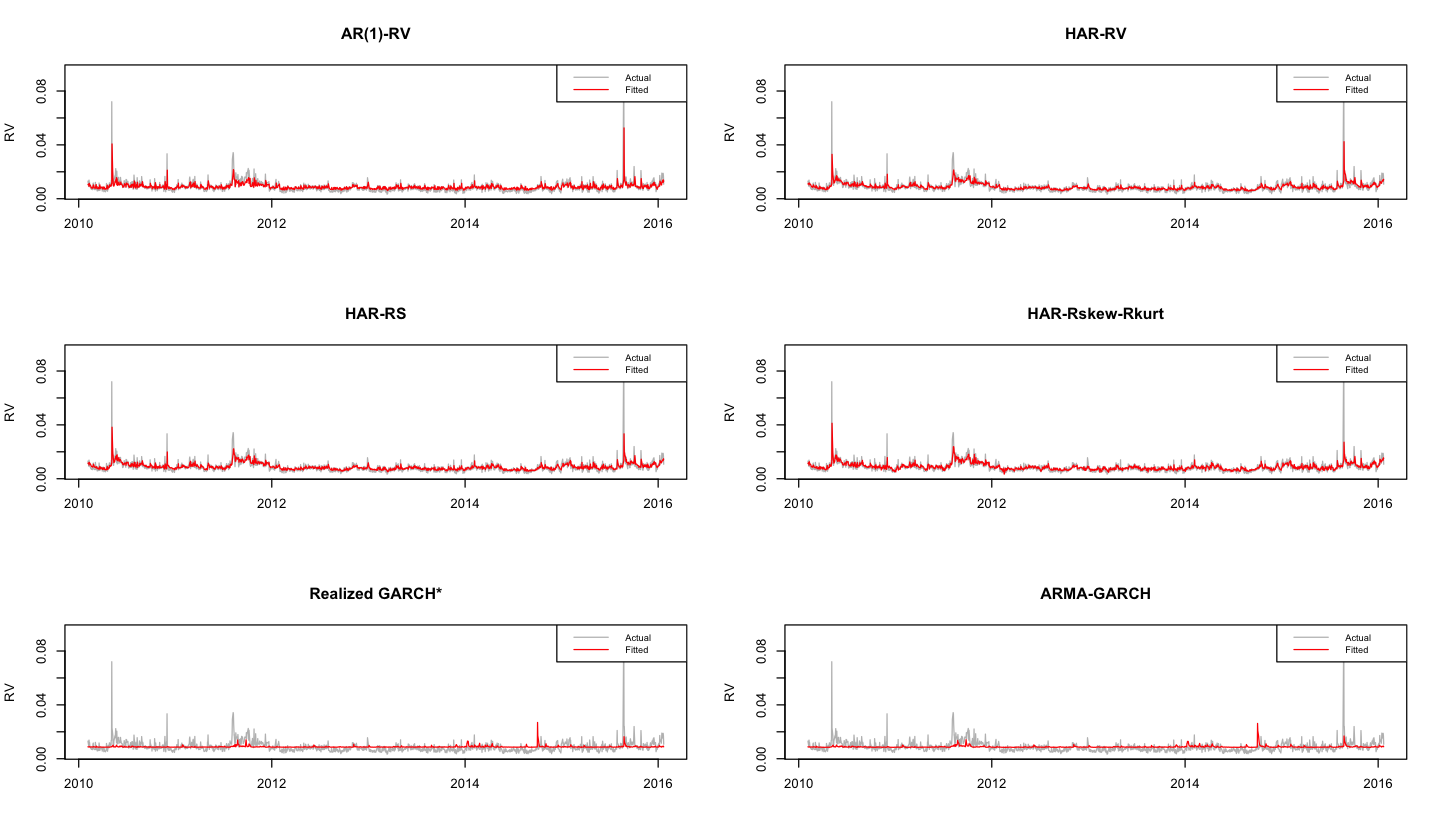

In [32]:
par(mfrow = c(3, 2))
for (i in seq_along(models)) {
  plot(model_df$date, actual, type = "l", col = "grey",
       main = names(models)[i], xlab = "", ylab = "RV")
  lines(model_df$date, fits[, i], col = "red")
  legend("topright", c("Actual", "Fitted"), col = c("grey", "red"), lty = 1, cex = 0.7)
}

**AR (1)** is the least complex model. It only has an $R^2$ of around 0.25 when including only one lag of RV. Adding weekly and monthly components, as in **HAR-RV**, improves results by approximately 0.30. These results indicate volatility persistence exists at more than one frequency. 

By introduction of weekly and monthly components, there's a further improvement in **HAR-RS** (around 0.32). The size of the negative semi-volatility effect is larger than the positive semi-volatility effect which is consistent with leverage type asymmetry. 

**HAR-Rskew-Rkurt** provides the highest in sample $R^2$ (nearly 0.33). The addition of kurtosis terms adds additional information on the top of semivariance split. 

**Both GARCH** models sit below the HAR family. Although they can map their estimated conditional variance back onto the RV scale through a measurement equation, the explanatory power of each model relative to RV will be much less. In other words, while GARCH models measure the conditional variance of returns, this is related to RV, but is not equivalent to it.